# Study 782 — CEO-Name-Length — for the quants 🔬

The full battery on a null-by-design characteristic: one-sample *t* of the monthly long/short, a label-shuffle placebo, a leave-one-ticker-out jackknife, alternate cuts, the costed net leg, and a seeded synthetic positive control. Everything offline once cached; fingerprint `a7f273eb002d`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ceo_name_length import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching 40 names + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ch = dt.characteristics()
rets = dt.monthly_returns(prices)
ls = st.long_short_series(rets, ch)
print(f"panel loaded; {rets.shape[0]} monthly cross-sections x {rets.shape[1]} names")


panel loaded; 137 monthly cross-sections x 40 names


## 1. The headline long/short and its (over-stated) *t*

One-sample *t* of the monthly LS return. Note the unit trap up front: the book is a **fixed** portfolio, so 137 months are *not* 137 independent bets — they're one decade-long sector tilt (Sharpe ≈ −0.9).

In [2]:
s = st.one_sample_t(ls.values); hr = st.hit_rate(ls.values)
print(f"n={s['n']}  mean={s['mean']*100:+.3f}%/mo  sd={s['sd']*100:.3f}%  t={s['t']:+.3f}  "
      f"Sharpe={st.sharpe(ls.values):+.2f}  hit {hr['k']}/{hr['n']}={hr['rate']*100:.1f}%")
spy = prices['SPY'].resample('ME').last().pct_change().reindex(rets.index)
beta = np.polyfit(spy.dropna().values, ls.reindex(spy.dropna().index).values, 1)[0]
print(f'realised LS beta to SPY = {beta:+.3f}  (dollar-neutral but NOT beta-neutral)')

n=137  mean=-0.930%/mo  sd=3.559%  t=-3.058  Sharpe=-0.91  hit 58/137=42.3%
realised LS beta to SPY = -0.308  (dollar-neutral but NOT beta-neutral)


## 2. Label-shuffle placebo — is the spread anything but tercile luck?

Permute the surname-length labels across the 40 names and recompute the LS mean; 20 seeds × 200 draws. If surname length carried information the observed spread would sit in the tail. It sits only *borderline* in the tail (two-tail p ≈ 0.04) — and that's before penalising the direction + spec search.

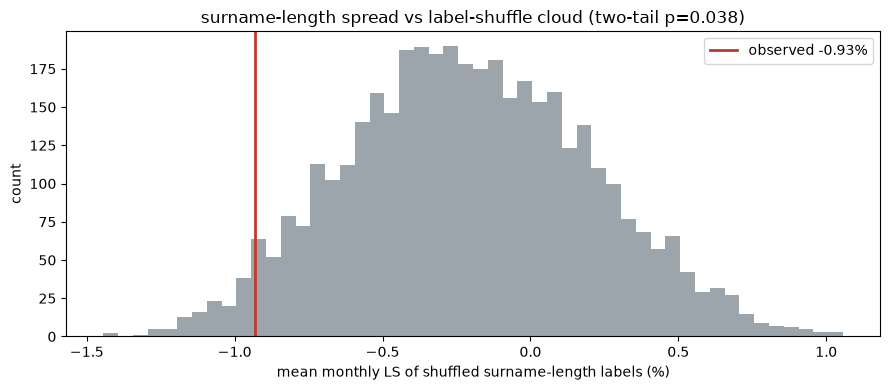

placebo: {'obs': -0.0093, 'placebo_mean': -0.0021, 'placebo_sd': 0.0041, 'p_value': 0.0385, 'n_draws': 4000}


In [3]:
pl = st.placebo_pvalue(rets, ch, tail='two')
vals = ch.values
rng = np.random.default_rng(4242); draws = []
for _ in range(4000):
    perm = pd.Series(rng.permutation(vals), index=ch.index)
    draws.append(float(st.long_short_series(rets, perm).mean()))
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.array(draws)*100, bins=50, color='#8b949e', alpha=0.85)
ax.axvline(pl['obs']*100, color='#c0392b', lw=2, label=f"observed {pl['obs']*100:+.2f}%")
ax.set_xlabel('mean monthly LS of shuffled surname-length labels (%)'); ax.set_ylabel('count')
ax.set_title(f"surname-length spread vs label-shuffle cloud (two-tail p={pl['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl.items()})

## 3. Jackknife — one name, or the whole cohort?

In [4]:
jk = st.jackknife_t(rets, ch)
print(f"full-sample t = {st.one_sample_t(ls.values)['t']:+.3f}")
print(f"jackknife t range [{jk['lo']:+.3f}, {jk['hi']:+.3f}] over {jk['n']} leave-one-out draws")
print('=> stable, but stability of a whole-cohort sector tilt is not evidence of a real signal')

full-sample t = -3.058
jackknife t range [-3.447, -2.232] over 40 leave-one-out draws
=> stable, but stability of a whole-cohort sector tilt is not evidence of a real signal


## 4. Alternate cuts + costs

The sign survives every breakpoint (the sector tilt is present at all of them), and costs make the short look 'stronger' — but it's an ex-post short-tech bet, not a repeatable edge.

In [5]:
for q, lab in [(0.20,'quintile'),(1/3,'tercile'),(0.50,'median')]:
    sq = st.one_sample_t(st.long_short_series(rets, ch, q=q).values)
    print(f'{lab:<9s} q={q:.2f}: mean {sq["mean"]*100:+.3f}%/mo  t={sq["t"]:+.2f}')
for cb in (0.0, 5.0, 10.0):
    sn = st.one_sample_t(st.long_short_series(rets, ch, cost_bps=cb).values)
    tag = 'gross' if cb == 0 else f'net@{cb:.0f}bps'
    print(f'{tag:<10s}: mean {sn["mean"]*100:+.3f}%/mo  t={sn["t"]:+.2f}')

quintile  q=0.20: mean -0.986%/mo  t=-2.17
tercile   q=0.33: mean -0.930%/mo  t=-3.06
median    q=0.50: mean -0.695%/mo  t=-3.48
gross     : mean -0.930%/mo  t=-3.06
net@5bps  : mean -1.030%/mo  t=-3.39
net@10bps : mean -1.130%/mo  t=-3.72


## 5. Synthetic positive control — the detector works, the real spread is a confound

The sort must stay quiet on an inert label (bump = 0) and recover a *planted* characteristic→return slope monotonically. It does — which is precisely why we trust that the real-tape −3.06 is a **confound**, not a planted slope: there is no mechanism to plant.

null: mean t=-0.23 sd=1.22  |t|>=2 in 2/20 seeds
planted +0.004: mean +0.876%/mo  t=+4.27
planted +0.008: mean +1.779%/mo  t=+8.66


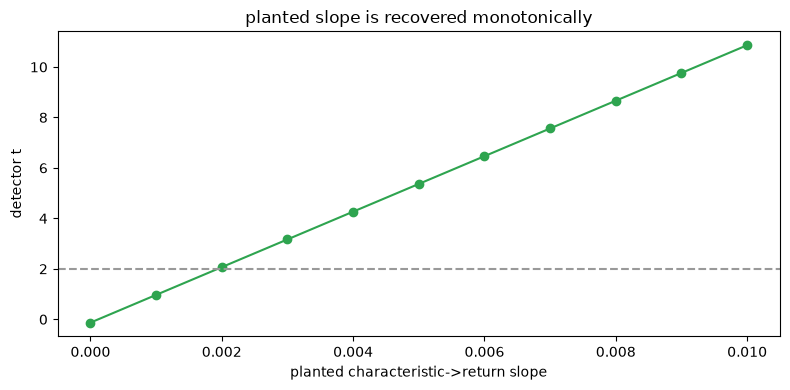

In [6]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=798+i)['t'] for i in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for b in (0.004, 0.008):
    r = st.synthetic_detect(bump=b, seed=798)
    print(f'planted +{b:.3f}: mean {r["mean"]*100:+.3f}%/mo  t={r["t"]:+.2f}')
bumps = np.linspace(0, 0.01, 11)
ts = [st.synthetic_detect(bump=b, seed=798)['t'] for b in bumps]
fig, ax = plt.subplots(figsize=(8, 4)); ax.plot(bumps, ts, 'o-', color='#2ea44f')
ax.axhline(2, color='0.6', ls='--'); ax.set_xlabel('planted characteristic->return slope'); ax.set_ylabel('detector t')
ax.set_title('planted slope is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: Weak.** The nominal stats cross the bar (*t* = -3.06, placebo two-tail p ≈ 0.04, jackknife-stable [-3.45, -2.23], consistent across cuts) so it is **not** noise — but it is a textbook confound: a static 2026 CEO snapshot turns the sort into a fixed short-tech/long-value bet (short leg = AAPL/AMZN/NVDA/TSLA/AMD), the monthly *t* overstates one ~11-yr portfolio (Sharpe -0.91, driven by 2020 & 2026), and there is zero mechanism. Real number, wrong cause. **Tradability: Mirage.** An unrepeatable, look-ahead-contaminated sector coincidence dressed up as a name-length factor.